In [48]:
import json


def stream_content():
    f = open(os.path.join(corpus_dir, "utterances.jsonl"))
    for jsonline in f:
        yield json.loads(jsonline)
        

In [49]:
approximators = ["kinda", "sorta", "sort of", "kind of", "pretty much", "basically", "more or less", "ish", "-ish"]
epistemic = ["maybe", "probably", "i think", "i guess", "i don't know", "i dunno", "dunno"]
general_extenders = ["stuff", "or something", "or whatever", "and all that"]
downtoners = ["just", "a bit", "somewhat"]

hedges = approximators + epistemic + general_extenders + downtoners

In [50]:
import re
from datetime import datetime, timezone

import pyarrow.parquet as pq

SENT_SPLIT = re.compile(r"[.!?\n]+")
TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)?")

class SentenceStream:
    def __init__(self, path, batch_size=10_000,
                 text_col="text", time_col="timestamp"):
        self.path = path
        self.batch_size = batch_size
        self.text_col = text_col
        self.time_col = time_col

    def __iter__(self):
        pf = pq.ParquetFile(path)
        for batch in pf.iter_batches(batch_size=self.batch_size,
                                          columns=[self.time_col, self.text_col]):
            for ts, text in zip(batch[self.time_col], batch[self.text_col]):
                ts, text = ts.as_py(), text.as_py()
                if ts is None or not text:
                    continue
                year = datetime.fromtimestamp(ts, timezone.utc).year
                for chunk in SENT_SPLIT.split(text):
                    chunk = chunk.strip()
                    if not chunk:
                        continue
                    toks = TOKEN.findall(chunk.lower())
                    if toks:
                        yield year, toks

In [51]:
corpus = pq.ParquetFile("/Volumes/RICK/work/cleaned/offmychest.parquet")

path = "/Volumes/RICK/work/cleaned/offmychest.parquet"

corpus_stream = SentenceStream(path)

print(next(iter(corpus_stream)))

(2013, ['i', 'gave', 'you', 'so', 'much', 'and', 'you', 'just', 'throw', 'us', 'out', 'like', 'that'])


In [52]:
from collections import defaultdict

word_freqs = {
    str(year): defaultdict(int)
    for year in range(2005, 2019)
}

for sentence in SentenceStream(corpus):
    year = str(sentence[0])

    for word in sentence[1]:
        word_freqs[year][word] += 1

KeyboardInterrupt: 

In [ ]:
import collections
import logging
import time

import pandas as pd

counts = collections.defaultdict(lambda: {"frequency": 0, "approximators": 0, "epistemic": 0, "general_extenders": 0, "downtoners": 0, "total": 0})
WINDOW = 5
OUT = "/Volumes/RICK/convokit/out_of_loop_hedging.csv"
date2ref = {y: str(y) for y in range(2005, 2019)}

start, n_sent, n_pairs = time.time(), 0, 0


for sentence in SentenceStream(corpus):
    year = str(sentence[0])
    n_sent += 1
    for i, word in enumerate(sentence[1]):
        idx = (year, word)
        
        # Inner loop matches your exact window logic
        for j in range(max(i-WINDOW, 0), min(i+WINDOW+1, len(sentence[1]))):
            counts[idx]["frequency"] += 1
            counts[idx]["approximators"] += int(word in approximators)
            counts[idx]["epistemic"] += int(word in epistemic)
            counts[idx]["general_extenders"] += int(word in general_extenders)
            counts[idx]["downtoners"] += int(word in downtoners)
            counts[idx]["total"] += int(word in hedges)
        
    if n_sent % 100_000 == 0:
        logging.info(f"Processed {n_sent} sentences in {time.time() - start:.2f} seconds")

# 2. Build the DataFrame all at once at the end
hedging_metrics = pd.DataFrame.from_dict(counts, orient='index')
hedging_metrics.index = pd.MultiIndex.from_tuples(hedging_metrics.index, names=['year', 'word'])
hedging_metrics.reset_index(inplace=True)

# 3. Save to file
hedging_metrics.to_csv(OUT, index=False)

KeyboardInterrupt: 

In [53]:
hedging_metrics = pd.read_parquet("/Volumes/RICK/work/hedging_counts.parquet")

In [67]:
hedging_metrics.head(10)

,word,year,frequency,approximators,epistemic,general_extenders,downtoners,hedged_any
0,a,2012,1239981,13347,35239,7031,84459,134466
1,a,2013,2863278,28911,79254,17095,187777,300318
2,a,2014,2960226,30365,85170,17882,196564,316040
3,a,2015,2321639,23135,67525,13329,154922,248281
4,a,2016,2021555,20282,61071,11841,134062,217453
5,a,2017,2635575,25553,83802,15703,172215,283861
6,a,2018,3473973,32290,110949,20383,229755,375767
7,a'aight,2014,1,0,0,0,0,0
8,a'all,2017,1,0,0,0,0,0
9,a'andre,2014,1,0,0,0,0,0


In [55]:
import pandas as pd

# per (word, year, subreddit) counts from the run
h = pd.read_parquet("/Volumes/RICK/work/hedging_counts.parquet")

# collapse to one row per word: total frequency and total hedged occurrences
g = h.groupby("word", as_index=False).agg(
    freq=("frequency", "sum"),
    obs=("hedged_any", "sum"),
)
g["raw_rate"] = g["obs"] / g["freq"]

# now the polysemy join
senses = json.load(open("senses.json"))
polysemy = {w: len(v) for w, v in senses.items() if isinstance(v, list)}
g["polysemy"] = g["word"].map(polysemy)
g = g[g["polysemy"].notna()].copy()
g["polysemy"] = g["polysemy"].astype(int)

In [56]:

with open("senses.json") as f:
    senses = json.load(f)

polysemy = {w: len(v) for w, v in senses.items() if isinstance(v, list)}


g["polysemy"] = g["word"].map(polysemy)
g = g[g["polysemy"].notna()]
g["polysemy"] = g["polysemy"].astype(int)

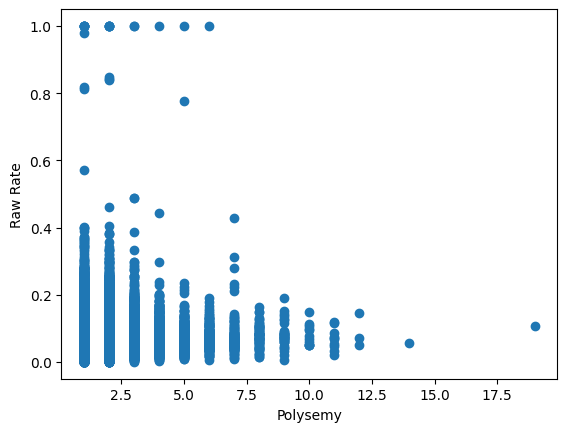

In [57]:
import matplotlib.pyplot as plt

xs, ys = g["polysemy"], g["raw_rate"]

plt.xlabel("Polysemy")
plt.ylabel("Raw Rate")
plt.scatter(xs, ys)

plt.show()

Text(0, 0.5, 'Raw rate')

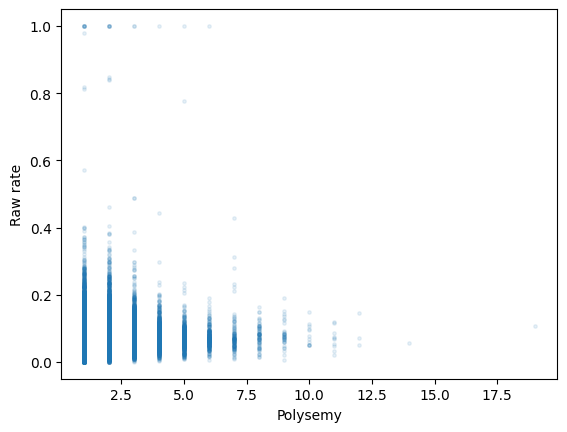

In [58]:
import json

senses = json.load(open("senses.json"))
polysemy = {w: len(v) for w, v in senses.items() if isinstance(v, list)}

g = h.groupby("word", as_index=False).agg(freq=("frequency","sum"), obs=("hedged_any","sum"))
g["raw_rate"] = g["obs"] / g["freq"]
g["polysemy"] = g["word"].map(polysemy)
g = g[g["polysemy"].notna()]

plt.scatter(g["polysemy"], g["raw_rate"], s=6, alpha=0.1)
plt.xlabel("Polysemy"); plt.ylabel("Raw rate")

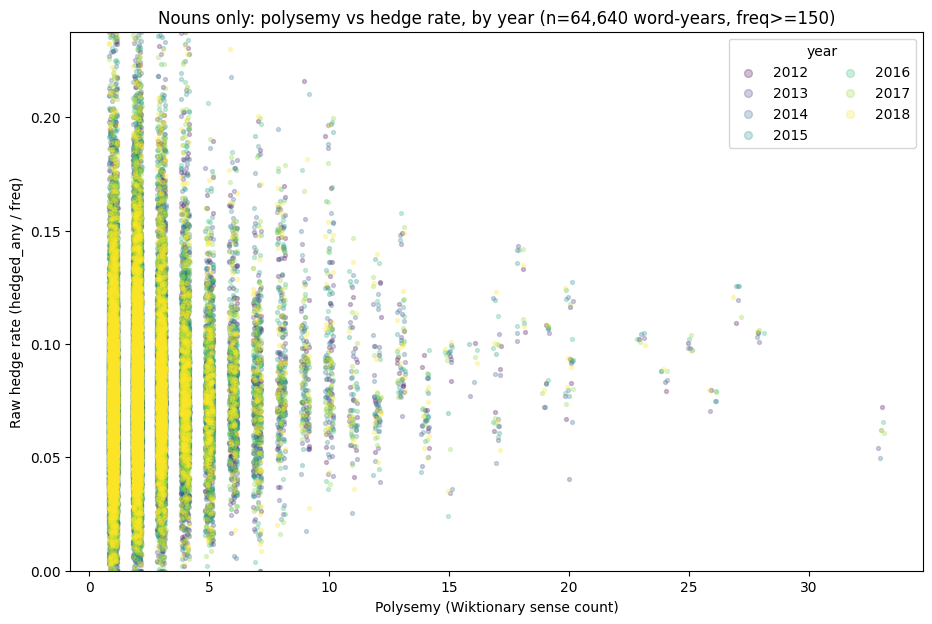

In [59]:
# Nouns only: polysemy vs raw hedge rate, one point per (word, year), colored by year.
# Uses the year-level parquet `h` (word, year, frequency, ..., hedged_any) loaded above.
import numpy as np

FLOOR = 150  # per (word, year) frequency floor, matches the project floor

# noun set + polysemy from senses.json (self-contained so this cell reproduces the sent figure)
_s = json.load(open("senses.json"))
def _is_noun(v):
    return any(isinstance(b, dict) and b.get("pos") == "noun" for b in v)
def _polysemy(v):
    n = sum(len(b.get("senses", [])) for b in v if isinstance(b, dict))
    return n if n > 0 else len(v)          # fallback to POS-block count when glosses are empty
nouns = {w for w, v in _s.items() if isinstance(v, list) and _is_noun(v)}
poly = {w: _polysemy(v) for w, v in _s.items() if isinstance(v, list)}

gy = h.groupby(["word", "year"], as_index=False).agg(freq=("frequency", "sum"),
                                                     obs=("hedged_any", "sum"))
gy["raw_rate"] = gy["obs"] / gy["freq"]
gy = gy[(gy["word"].isin(nouns)) & (gy["freq"] >= FLOOR)].copy()
gy["polysemy"] = gy["word"].map(poly)

fig, ax = plt.subplots(figsize=(11, 7))
years = sorted(gy["year"].unique())
cmap = plt.get_cmap("viridis")
rng = np.random.default_rng(0)  # seeded jitter so integer polysemy doesn't overplot
for i, y in enumerate(years):
    s = gy[gy["year"] == y]
    ax.scatter(s["polysemy"] + rng.uniform(-.18, .18, len(s)), s["raw_rate"],
               s=8, alpha=0.25, color=cmap(i / (len(years) - 1)), label=str(y))
ax.set_xlabel("Polysemy (Wiktionary sense count)")
ax.set_ylabel("Raw hedge rate (hedged_any / freq)")
ax.set_title(f"Nouns only: polysemy vs hedge rate, by year "
             f"(n={len(gy):,} word-years, freq>={FLOOR})")
ax.set_ylim(0, min(0.5, gy["raw_rate"].quantile(.995)))
ax.legend(title="year", markerscale=2, ncol=2)
plt.show()

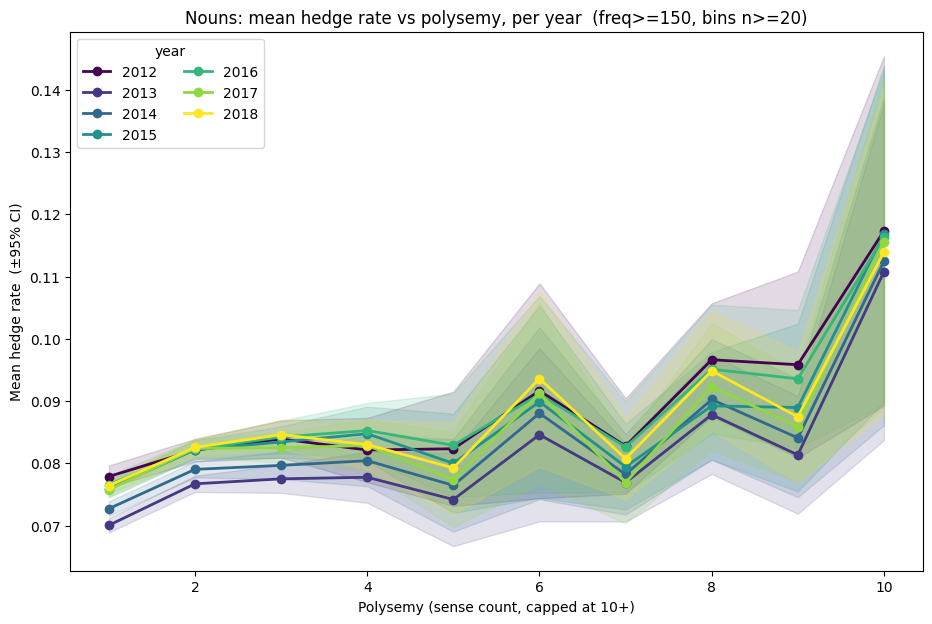

In [60]:
# Legible version: mean hedge rate +/- 95% CI vs polysemy, one line per year.
# Reuses `gy` (nouns, freq>=FLOOR, with `polysemy`) built in the cell above.
CAP = 10       # collapse the sparse high-polysemy tail into a "10+" bin
MIN_BIN = 20   # drop (year, polysemy) cells with too few words to be meaningful

b = gy.copy()
b["pbin"] = b["polysemy"].clip(upper=CAP)
agg = b.groupby(["year", "pbin"])["raw_rate"].agg(["mean", "std", "count"]).reset_index()
agg = agg[agg["count"] >= MIN_BIN]
agg["ci"] = 1.96 * agg["std"] / np.sqrt(agg["count"])

fig, ax = plt.subplots(figsize=(11, 7))
cmap = plt.get_cmap("viridis")
years = sorted(agg["year"].unique())
for i, y in enumerate(years):
    s = agg[agg["year"] == y].sort_values("pbin")
    c = cmap(i / (len(years) - 1))
    ax.plot(s["pbin"], s["mean"], "o-", color=c, lw=2, label=str(y))
    ax.fill_between(s["pbin"], s["mean"] - s["ci"], s["mean"] + s["ci"], color=c, alpha=0.15)
ax.set_xlabel(f"Polysemy (sense count, capped at {CAP}+)")
ax.set_ylabel("Mean hedge rate  (±95% CI)")
ax.set_title(f"Nouns: mean hedge rate vs polysemy, per year  (freq>={FLOOR}, bins n>={MIN_BIN})")
ax.legend(title="year", ncol=2)
plt.show()

In [61]:
# Interactive: click a year in the legend to toggle it; DOUBLE-click to isolate one year's trend.
# Same binned means +/- 95% CI as above, rendered with plotly.
import plotly.graph_objects as go

fig = go.Figure()
for i, y in enumerate(years):
    s = agg[agg["year"] == y].sort_values("pbin")
    rgb = tuple(int(255 * c) for c in cmap(i / (len(years) - 1))[:3])
    fig.add_trace(go.Scatter(
        x=s["pbin"], y=s["mean"], name=str(y), mode="lines+markers",
        line=dict(color=f"rgb{rgb}", width=2),
        error_y=dict(type="data", array=s["ci"], visible=True, thickness=1),
        hovertemplate=f"year {y}<br>polysemy=%{{x}}<br>hedge rate=%{{y:.3f}}<extra></extra>",
    ))
fig.update_layout(
    title=f"Nouns: mean hedge rate vs polysemy, per year (freq>={FLOOR}) — "
          "click legend to toggle, double-click to isolate",
    xaxis_title=f"Polysemy (sense count, capped at {CAP}+)",
    yaxis_title="Mean hedge rate (±95% CI)",
    legend_title="year", template="plotly_white", height=600,
)
fig.show()

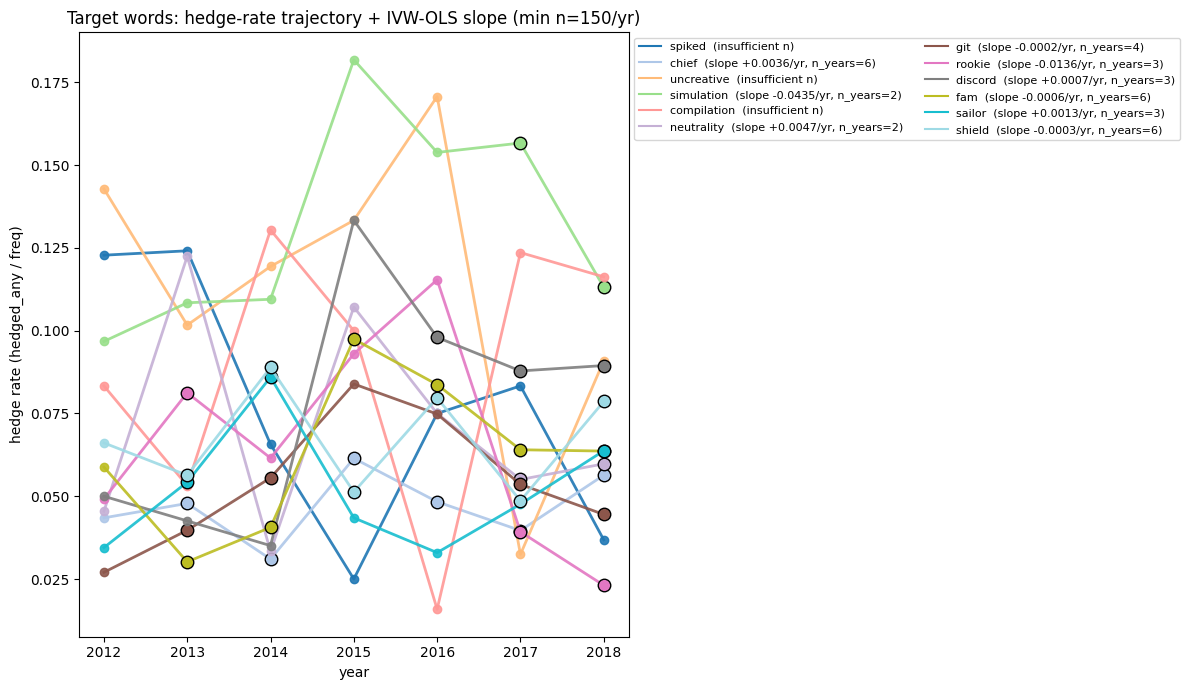

In [66]:
# Per-year hedge-rate trajectory + inverse-variance-weighted OLS slope
import matplotlib.pyplot as plt
import numpy as np

TARGETS = ["spiked", "chief", "uncreative", "simulation", "compilation",
           "neutrality", "git", "rookie", "discord", "fam", "sailor", "shield"]

MIN_N = 150  # drop years below this frequency floor before fitting

t = h[h["word"].isin(TARGETS)].copy()
t["rate"] = t["hedged_any"] / t["frequency"]

fig, ax = plt.subplots(figsize=(12, 7))
cmap = plt.get_cmap("tab20", len(TARGETS))  # tab20 avoids color collisions past 10 lines

for i, w in enumerate(TARGETS):
    s = t[t["word"] == w].sort_values("year")

    # plot full (unfiltered) trajectory so you can still see what got dropped
    ax.plot(s["year"], s["rate"], "o-", color=cmap(i), lw=2, alpha=0.9)

    # filter to sub-floor-excluded years for the slope fit
    s_fit = s[s["frequency"] >= MIN_N]
    if len(s_fit) < 2:
        ax.plot([], [], color=cmap(i), label=f"{w}  (insufficient n)")
        continue

    p = s_fit["rate"].values
    n = s_fit["frequency"].values
    # inverse-variance weights from binomial approximation; clip to avoid div-by-zero
    var = np.clip(p * (1 - p) / n, 1e-8, None)
    weights = 1 / var

    slope, intercept = np.polyfit(s_fit["year"], s_fit["rate"], deg=1, w=weights)

    # mark which years actually went into the fit
    ax.plot(s_fit["year"], s_fit["rate"], "o", color=cmap(i), markersize=9,
             markeredgecolor="black", markeredgewidth=1)

    ax.plot([], [], color=cmap(i), label=f"{w}  (slope {slope:+.4f}/yr, n_years={len(s_fit)})")

ax.set_xlabel("year")
ax.set_ylabel("hedge rate (hedged_any / freq)")
ax.set_title(f"Target words: hedge-rate trajectory + IVW-OLS slope (min n={MIN_N}/yr)")
ax.legend(ncol=2, fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

In [71]:
# Nouns only: keep words whose Wiktionary senses mark them as nouns
top_hedged = (
    h[h["word"].isin(nouns)]
    .groupby("word", as_index=False)
    .agg(
        total_hedged=("hedged_any", "sum"),
        total_freq=("frequency", "sum"),
    )
    .sort_values("total_hedged", ascending=False)
)

top_hedged["hedge_rate"] = top_hedged["total_hedged"] / top_hedged["total_freq"]
print(top_hedged.head(20))

        word  total_hedged  total_freq  hedge_rate
11312   just       4911525     4911525    1.000000
10345      i       4374632    27918960    0.156690
668      and       2108737    20786425    0.101448
0          a       1876186    17516227    0.107111
23830    you       1490133    16918498    0.088077
11048     it       1365164    11443936    0.119291
21298   that       1225024    11073944    0.110622
21359  think        993952     2038507    0.487588
2841     but        907868     6784814    0.133809
11023     is        834280     8617888    0.096808
12766  maybe        749999      749999    1.000000
6224   don't        680626     3384744    0.201086
14455     or        636560     3554514    0.179085
11545   know        624377     2734088    0.228368
10527     in        623091     8276079    0.075288
12014   like        622108     4596845    0.135334
12780     me        592415     6749167    0.087776
21373   this        588376     5757920    0.102186
1648      be        588204     